# cutout

> Cutout specific region out of a stacked image. This is mostly superceded by `nicl.euclid.combine`,
> but may still be useful.

In [ ]:
# | default_exp euclid.cutout

In [ ]:
# | exporti

from pathlib import Path

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import SkyCoord
from astropy.io import fits
from astropy.nddata import Cutout2D
from astropy.units import Quantity
from astropy.visualization import PercentileInterval, AsinhStretch, ImageNormalize
from astropy.visualization.wcsaxes import SphericalCircle
from astropy.wcs import WCS
from matplotlib.patches import Polygon
from reproject import reproject_interp
from reproject.mosaicking import reproject_and_coadd

from nicl.utilities import maybe_to_value
from nicl.euclid.data_access import DataAccess
from nicl.euclid.utilities import get_nisp_dither, get_nisp_tile, get_nisp_stack

In [ ]:
# | hide

from astropy.nddata import CCDData

from nicl.utilities import physical_to_angular
from nicl.euclid.utilities import default_data_path, find_single_file

In [ ]:
# | export


def get_cutout_and_save(
    image_path,  # full directory of the input FITS file containing the image data
    cutout_size,  # side length of the cutout (either as in degrees or as an angular Quantity)
    output_path,  # directory where the cutout image will be saved
    cutout_name,  # name used to construct the output filename
    ext_match=None,  # optional string to match against extensions name, otherwise will cut out all extensions
    ra=None,  # RA of the cutout center (in degrees or as an angular Quantity), centre of the image if not provided
    dec=None,  # Dec of the cutout center (in degrees or as an angular Quantity), centre of the image if not provided
    mode: {'trim', 'partial', 'strict'} = "partial",  # mode for Cutout2D, forced to be "partial" if `overlay` is True
    overlay=True,  # overlay multiple science extensions in a single image
    wcs_out=None,  # optional output wcs if overlaying multiple science extensions
    shape_out=None,  # optional output shape if overlaying multiple science extensions
):  # filename of the saved cutout and SkyCoord of the center of the cutout
    """Extract and save a cutout image from a given larger image."""
    if overlay:
        mode = "partial"
        ext_match = "SCI"        
    with fits.open(image_path, memmap=True, do_not_scale_image_data=True) as hdul:
        if len(hdul) == 1:
            ext_list = [0]
        elif ext_match is not None:
            ext_list = [hdu.name for hdu in hdul if ext_match in hdu.name]
        else:
            ext_list = [hdu.name for hdu in hdul]
        output_hdul = fits.HDUList()
        for ext in ext_list:
            hdu = hdul[ext]
            data = hdu.data
            if data is not None:
                header = hdu.header
                wcs = WCS(header)
                if ra is None or dec is None:
                    centre_pixel = (np.array(data.shape) - 1) / 2
                    centre = wcs.pixel_to_world(*centre_pixel)
                    ext_ra = centre.ra if ra is None else ra
                    ext_dec = centre.dec if dec is None else dec
                else:
                    ext_ra = ra
                    ext_dec = dec
                ext_ra, ext_dec, cutout_size = u.Quantity(
                    (ext_ra, ext_dec, cutout_size), u.deg
                )
                position = SkyCoord(ra=ext_ra, dec=ext_dec, frame="icrs")
                try:
                    cutout = Cutout2D(data, position, cutout_size, wcs=wcs, mode=mode)
                except:
                    pass
                else:
                    MatchingHDU = type(hdu)
                    # Update the FITS header with the cutout WCS
                    cutout_header = header.copy()
                    cutout_header.update(cutout.wcs.to_header())
                    out_hdu = MatchingHDU(data=cutout.data, header=cutout_header)
                    output_hdul.append(out_hdu)
    if (overlay and len(output_hdul) > 1) or wcs_out is not None:
        print("Reprojecting image(s)")
        hdu = output_hdul[0]
        if wcs_out is None:
            wcs_out = WCS(hdu.header)
        if shape_out is None:
            shape_out = hdu.shape
        array, footprint = reproject_and_coadd(output_hdul,
                                       wcs_out, shape_out=shape_out,
                                       reproject_function=reproject_interp,
                                       blank_pixel_value=np.nan)
        hdu.data = array
        hdu.header.update(wcs_out.to_header())
        output_hdul = fits.HDUList(hdu)
    output_path = Path(output_path)
    output_path.mkdir(parents=True, exist_ok=True)
    fn = output_path / f"{cutout_name}.fits"
    output_hdul.writeto(fn, overwrite=True)
    return fn, position

In [ ]:
# | export


def cutout(
    ra,  # RA of the cutout center (in degrees or as an angular Quantity), centre of the image if not provided
    dec,  # Dec of the cutout center (in degrees or as an angular Quantity), centre of the image if not provided
    size,  # side length of the cutout (either as in degrees or as an angular Quantity)
    file_type: {"MER", "STK", "CAL"},  # which type of image to cut out
    input_path,  # path to search for the required input image file
    output_path,  # path to folder in which to output cutout image file
    cutout_name,  # name used to construct the output filename
    filter,  # the filter for the cutout
    dither=0,  # which dither to use if `file_type` is "CAL"
    mode: {'trim', 'partial', 'strict'} = "partial",  # mode for Cutout2D
    overlay=True,  # overlay multiple science extensions in a single image
    wcs_out=None,  # optional output wcs if overlaying multiple science extensions
    shape_out=None,  # optional output shape if overlaying multiple science extensions
    da=None,  # optional DataAccess object, to avoid recreating one for each cutout
):  # filename of the saved cutout
    if da is None:
        da = DataAccess()
    if file_type == "MER":
        ids = da.find_tiles_for_target(ra, dec, size / 2, fully_contained=True)
    elif file_type in ("CAL", "STK"):
        ids = da.find_observations_for_target(ra, dec, size / 2, fully_contained=True)
    else:
        raise ValueError(f"Invalid file_type provided: {file_type}.")
    if len(ids) == 0:
        if file_type == "MER":
            ids = da.find_tiles_for_target(ra, dec, size / 2, fully_contained=False)
        elif file_type in ("CAL", "STK"):
            ids = da.find_observations_for_target(
                ra, dec, size / 2, fully_contained=False
            )
    if len(ids) == 0:
        raise FileNotFoundError("No images found for target.")
    if len(ids) > 1:
        raise NotImplementedError(
            "Automatic stacking of multiple pointings not implemented. Use `nicl.euclid.combine`."
        )
    else:
        ids = ids[0]
        try:
            if file_type == "MER":
                fn = get_nisp_tile(ids, filter=filter, path=input_path)
            elif file_type == "CAL":
                fn = get_nisp_dither(ids, dither=dither, filter=filter, path=input_path)
            elif file_type == "STK":
                fn = get_nisp_stack(ids, filter=filter, path=input_path)
        except FileNotFoundError:
            fn = None
        if fn is None:
            raise NotImplementedError(
                "Automatic stacking of single pointing not implemented. Use `nicl.euclid.combine`."
            )
    cutout_name = f"{cutout_name}_{filter}"
    fn, position = get_cutout_and_save(
        fn, size, output_path, cutout_name, ra=ra, dec=dec, mode=mode, overlay=overlay, wcs_out=wcs_out, shape_out=shape_out
    )
    return fn

In [ ]:
# | export


def show_image(
    image_data,  # 2D array of the image data to display
    image_wcs,  # WCS object associated with the image
    intervalpc=95,  # percentile range to display
    ra=None,  # RA of the center (in degrees or as an angular Quantity) for the region to outline
    dec=None,  # Dec of the center (in degreesor as an angular Quantity) for the region to outline
    radius=None,  # radius of circle or half side length of box to be outlined (in degrees or as an angular Quantity)
    outline_shape=None,  # shape of the region to outline ('circle' or 'box')
):
    """Display an image and optionally outlines a region around a given RA, Dec."""
    interval = PercentileInterval(intervalpc)
    norm = ImageNormalize(image_data, interval=interval, stretch=AsinhStretch())

    fig, ax = plt.subplots(subplot_kw={"projection": image_wcs})
    im = ax.imshow(
        image_data, norm=norm, origin="lower", cmap="Greys", interpolation="nearest"
    )

    if ra is not None and dec is not None:
        ra, dec = Quantity((ra, dec), u.deg)
        Centre = SkyCoord(ra=ra, dec=dec, frame="icrs")

        ax.scatter(
            Centre.ra.deg,
            Centre.dec.deg,
            marker="x",
            s=50,
            c="red",
            transform=ax.get_transform("fk5"),
        )

        if outline_shape == "circle" and radius is not None:
            circle = SphericalCircle(
                (Centre.ra, Centre.dec),
                radius,
                edgecolor="cyan",
                facecolor="none",
                transform=ax.get_transform("fk5"),
            )
            ax.add_patch(circle)

        elif outline_shape == "box" and radius is not None:
            radius_deg = maybe_to_value(radius, u.deg)

            # Scaling RA offset by cos(Dec) to ensure equal angular side lengths
            ra_offset = radius_deg / np.cos(np.radians(dec))

            corners = [
                (ra - ra_offset, dec - radius_deg),  # Bottom-left
                (ra - ra_offset, dec + radius_deg),  # Top-left
                (ra + ra_offset, dec + radius_deg),  # Top-right
                (ra + ra_offset, dec - radius_deg),  # Bottom-right
            ]

            poly = Polygon(
                corners,
                closed=True,
                edgecolor="yellow",
                facecolor="none",
                transform=ax.get_transform("fk5"),
            )
            ax.add_patch(poly)

    plt.colorbar(im, ax=ax, orientation="vertical", label="Pixel Intensity")
    plt.xlabel("RA (J2000)")
    plt.ylabel("Dec (J2000)")

## Example

The following is an example of creating a cutout for a cluster.

In [ ]:
cluster_id = "MCXCJ1754.6+6803"
z = 0.07
ra = 268.662 * u.deg
dec = 68.058 * u.deg
cutout_radius_physical = 150 * u.kpc
path = default_data_path("Q1_R1")
cluster_path = default_data_path("Q1_R1_clusters_test", cluster_id)
cutout_size_angular = 2 * physical_to_angular(cutout_radius_physical, z)
cutout_name = f"{cluster_id}_MER"
fn = cutout(
    ra,
    dec,
    cutout_size_angular,
    file_type="MER",
    input_path=path,
    output_path=cluster_path,
    cutout_name=cutout_name,
    filter="H",
)

INFO: OK [astroquery.utils.tap.core]


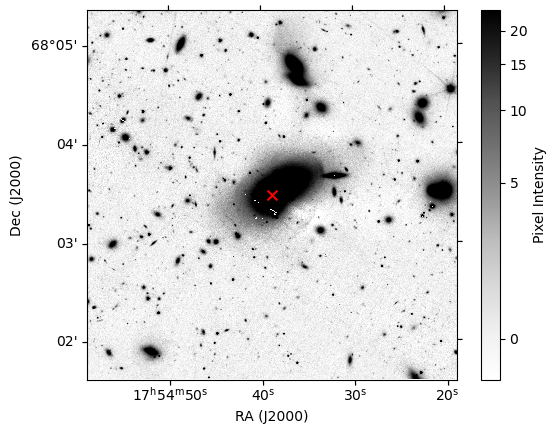

In [ ]:
image_mer = CCDData.read(fn, unit=u.dimensionless_unscaled)
show_image(image_mer.data, image_mer.wcs, ra=ra, dec=dec)

In [ ]:
fn = f"EUC_NIR_W-CAL-IMAGE_H-2683-3_*.fits"
fn = find_single_file(fn, default_data_path("Q1_R1"))
cluster_path = default_data_path("Q1_R1_clusters_test", cluster_id)
cutout_name = f"{cluster_id}_CAL"
cal_cutout_fn, centre = get_cutout_and_save(
    fn,
    cutout_size_angular * 1.5,
    output_path=cluster_path,
    cutout_name=cutout_name,
    ra=ra,
    dec=dec,
    mode="partial",
    wcs_out=image_mer.wcs,
    shape_out=image_mer.shape,
)

Reprojecting image(s)


INFO: using the unit  passed to the FITS reader instead of the unit ELECTRON in the FITS file. [astropy.nddata.ccddata]


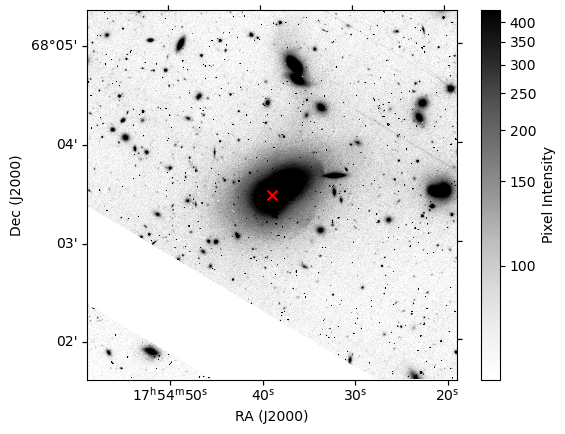

In [ ]:
image_cal = CCDData.read(cal_cutout_fn, unit=u.dimensionless_unscaled)
show_image(image_cal.data, image_mer.wcs, ra=ra, dec=dec)

In [ ]:
# | hide
import nbdev

nbdev.nbdev_export()